# 미니프로젝트: 머신러닝 프로세스 (Vibe Coding)

#### <목표>
오늘 배운 머신러닝 프로세스를 **제조 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- AI4I 2020 Predictive Maintenance (예지 정비)
- 10,000개 제조 장비 운전 데이터

| 변수명 | 설명 |
|:---:|:---|
| Type | 제품 품질 등급 (L: Low, M: Medium, H: High) |
| Air temperature | 공기 온도 [K] |
| Process temperature | 공정 온도 [K] |
| Rotational speed | 회전 속도 [rpm] |
| Torque | 토크 [Nm] |
| Tool wear | 공구 마모 시간 [min] |
| Machine failure | 기계 고장 여부 (0: 정상, 1: 고장) |
| TWF, HDF, PWF, OSF, RNF | 고장 유형별 발생 여부 |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 회귀 | `Torque` | 운전 조건(온도, 회전속도, 공구마모 등)으로 토크 예측 |
| 분류 | `Machine failure` | 운전 조건으로 기계 고장 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day1_miniproject.csv` 파일을 사용하기
- 하나의 원본 데이터에서 태스크별로 데이터프레임을 분리하기
    - **회귀용 (Regression):** 타겟 = `Torque`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Tool wear
    - **분류용 (Classification):** 타겟 = `Machine failure`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear

**[과제]** 써니는 오늘부로 제조 설비 운전 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 불러오고, 회귀용/분류용 데이터셋을 각각 어떻게 구성해야 할지 AI와 상의해서 코드를 작성하세요.

In [2]:
# ===== 기본 데이터 처리 =====
import pandas as pd
import numpy as np

# ===== 시각화 =====
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 통계 검정 (이상치/정규성 확인용) =====
from scipy.stats import shapiro

# ===== 데이터 분할 =====
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV

# ===== 전처리 (인코딩 / 스케일링) =====
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

# ===== 회귀 모델 =====
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ===== 분류 모델 =====
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ===== 부스팅 모델 (회귀/분류 공용) =====
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# ===== 성능 평가 =====
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,          # 회귀 지표
    accuracy_score, recall_score, precision_score, f1_score,    # 분류 지표
    roc_auc_score, confusion_matrix,
)

# ===== 출력 설정 (선택) =====
pd.set_option("display.max_columns", None)
plt.rcParams["axes.unicode_minus"] = False   # 그래프 마이너스 기호 깨짐 방지

In [26]:
#한글폰트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "AppleGothic"   # macOS 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 기호 깨짐 방지

In [3]:
# 노트북(8일차) 기준 상대경로 — NameError 원인이었던 pd 미정의 문제 해결됨
df = pd.read_csv("dataset/day1_miniproject.csv")

# 회귀용: Torque 예측
reg_cols = ["Type", "Air temperature", "Process temperature", "Rotational speed", "Tool wear", "Torque"]
Regression = df[reg_cols].copy()

# 분류용: Machine failure 예측
cla_cols = ["Type", "Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear", "Machine failure"]
Classification = df[cla_cols].copy()

print(Regression.shape, Classification.shape)
Regression.head()

(10000, 6) (10000, 7)


,Type,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
0,M,298.1,308.6,1551,0,42.8
1,L,298.2,308.7,1408,3,46.3
2,L,298.1,308.5,1498,5,49.4
3,L,298.2,308.6,1433,7,39.5
4,L,298.2,308.7,1408,9,40.0


---
## 1) 데이터 탐색 (EDA)

### 1-1) Value 기반 탐색

**[과제]** 써니는 본격적인 분석에 앞서 데이터가 어떻게 생겼는지 먼저 파악하고 싶습니다. AI와 어떠한 데이터 정보를 확인하면 좋을지 상의해보고 관련 정보를 확인해보세요.

In [5]:
# 1. 데이터 크기
print("Regression shape:", Regression.shape)
print("Classification shape:", Classification.shape)

Regression shape: (10000, 6)
Classification shape: (10000, 7)


In [6]:
# 2. 컬럼 타입 + 결측치 개요 (한 번에 확인)
Regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Tool wear            10000 non-null  int64  
 5   Torque               10000 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 468.9+ KB


In [7]:
Classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [16]:
# 4. 수치형 변수 통계 요약 (평균, 표준편차, min/max, 사분위수)
Regression.describe()

,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,107.951000,39.986910
std,2.000259,1.483734,179.284096,63.654147,9.968934
min,295.300000,305.700000,1168.000000,0.000000,3.800000
25%,298.300000,308.800000,1423.000000,53.000000,33.200000
50%,300.100000,310.100000,1503.000000,108.000000,40.100000
75%,301.500000,311.100000,1612.000000,162.000000,46.800000
max,304.500000,313.800000,2886.000000,253.000000,76.600000


In [15]:
# 5. 범주형 변수(Type) 분포 확인
print(Regression["Type"].value_counts())
print(Regression["Type"].value_counts(normalize=True) * 100)  # 비율(%)

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


In [12]:
# 6. 결측치 개수 (컬럼별)
print(Regression.isnull().sum())

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Tool wear              0
Torque                 0
dtype: int64


In [13]:
# 7. 중복 행 확인
print("중복 행 개수:", Regression.duplicated().sum())

중복 행 개수: 0


In [14]:
# 8. 고유값 개수 (상수 변수·이상 범주 여부 확인용)
Regression.nunique()

Type                     3
Air temperature         93
Process temperature     82
Rotational speed       941
Tool wear              246
Torque                 577
dtype: int64

### 1-2) Graph 기반 탐색

#### 1-2-1) 단일 변수 분포

**[과제]** 써니는 변수들의 분포가 어떤 모양인지 한눈에 살펴보고 싶습니다. 여러 수치형 변수를 효율적으로 한 번에 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

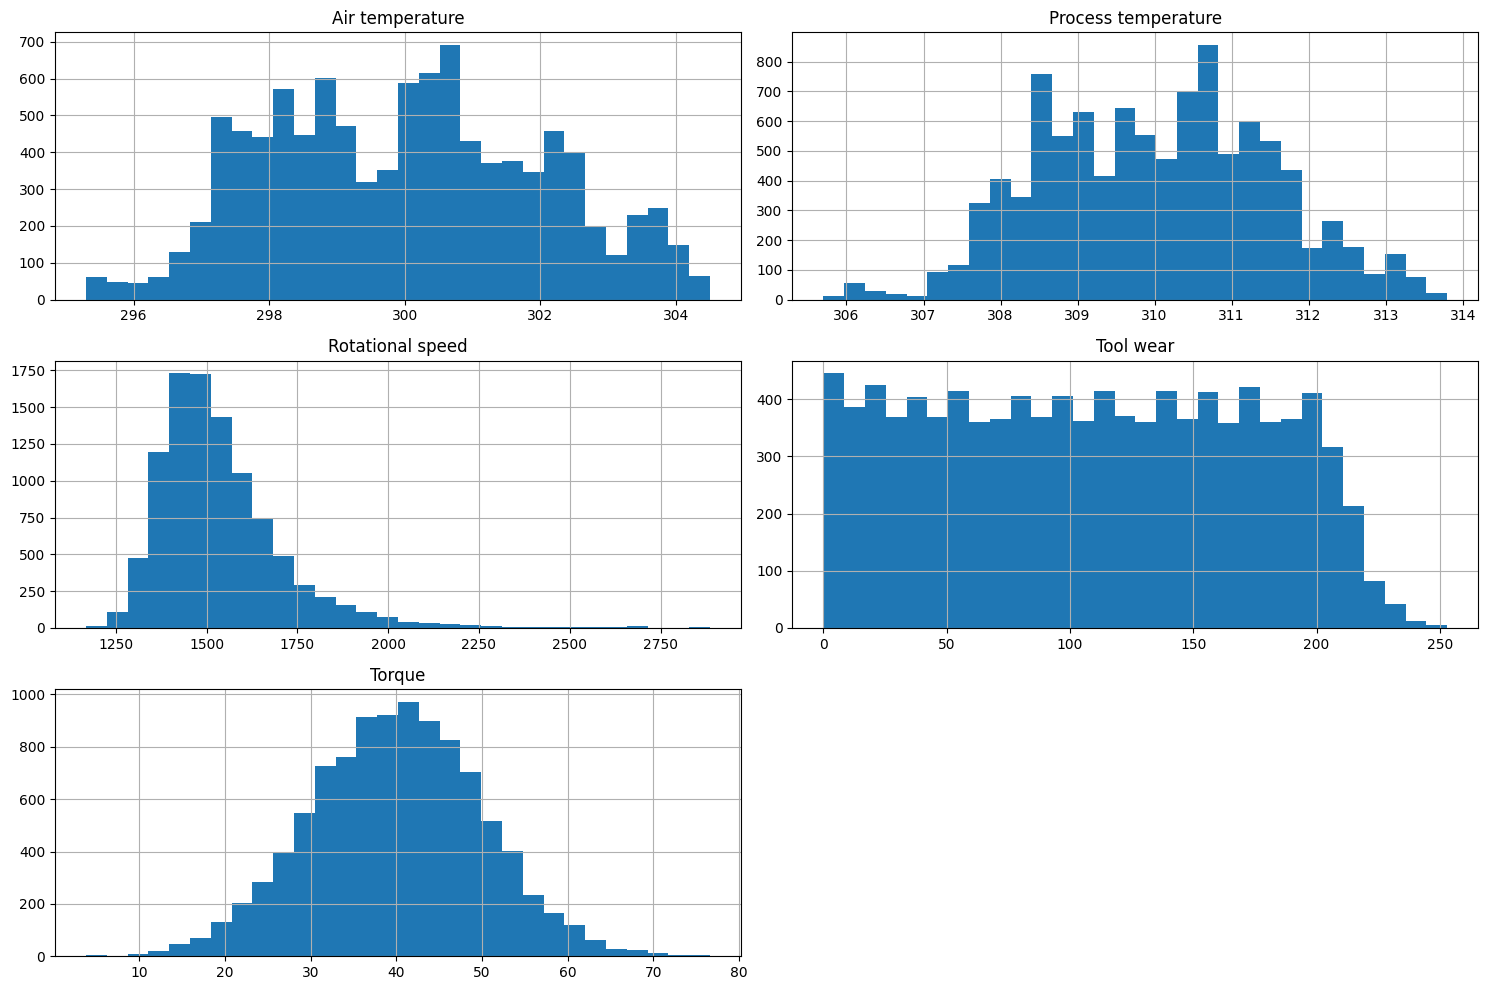

In [17]:
Regression.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

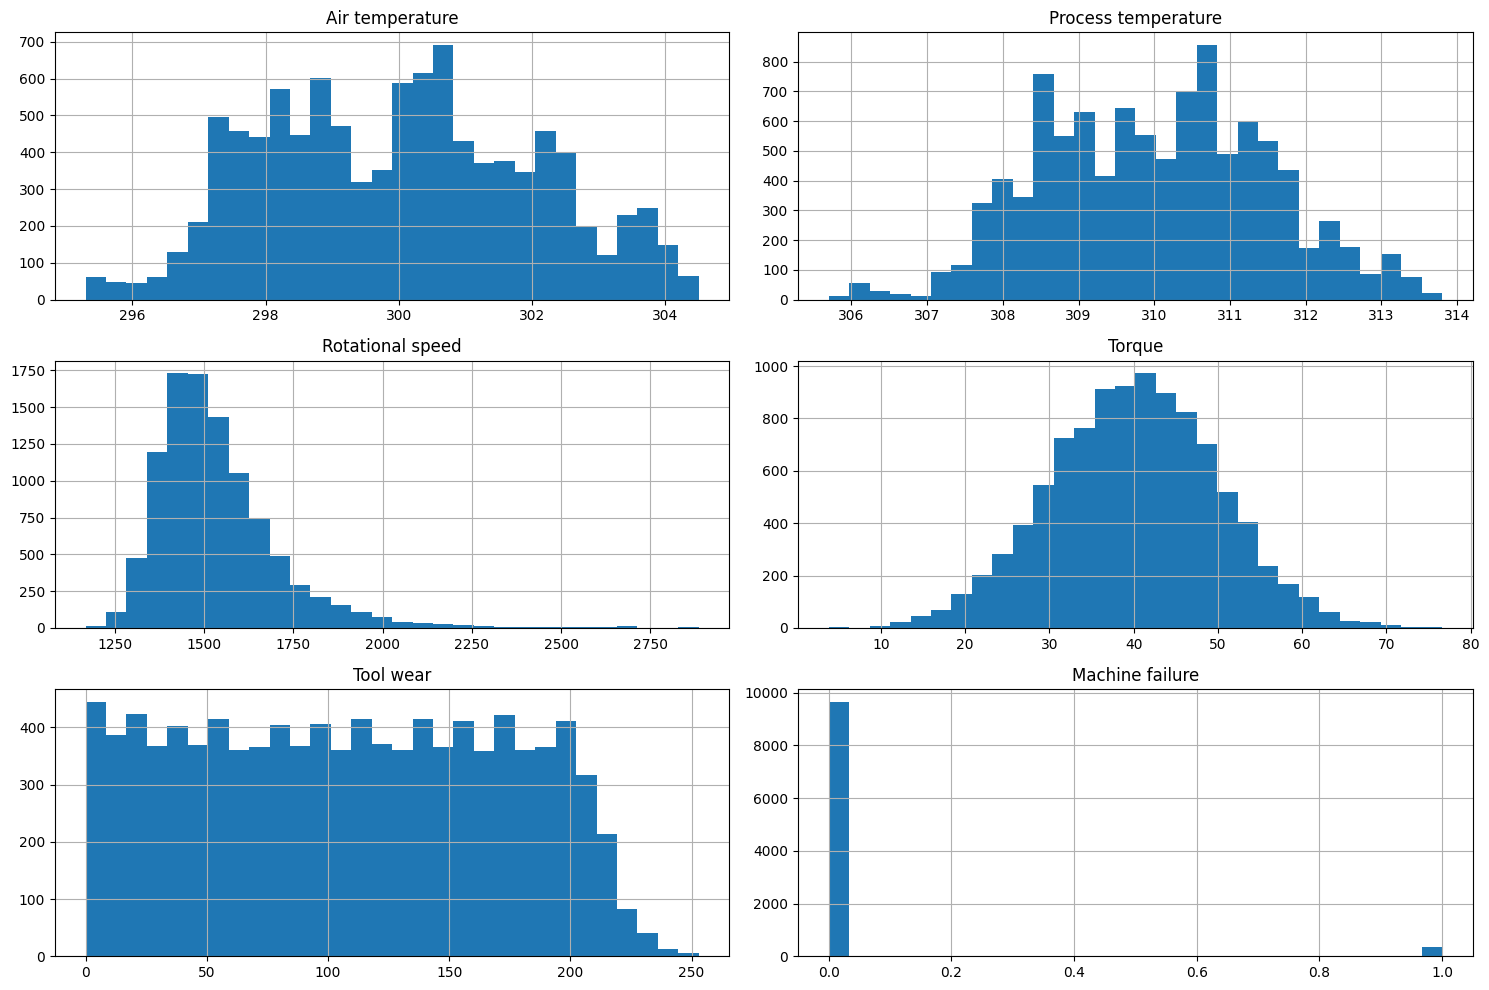

In [18]:
Classification.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/ho

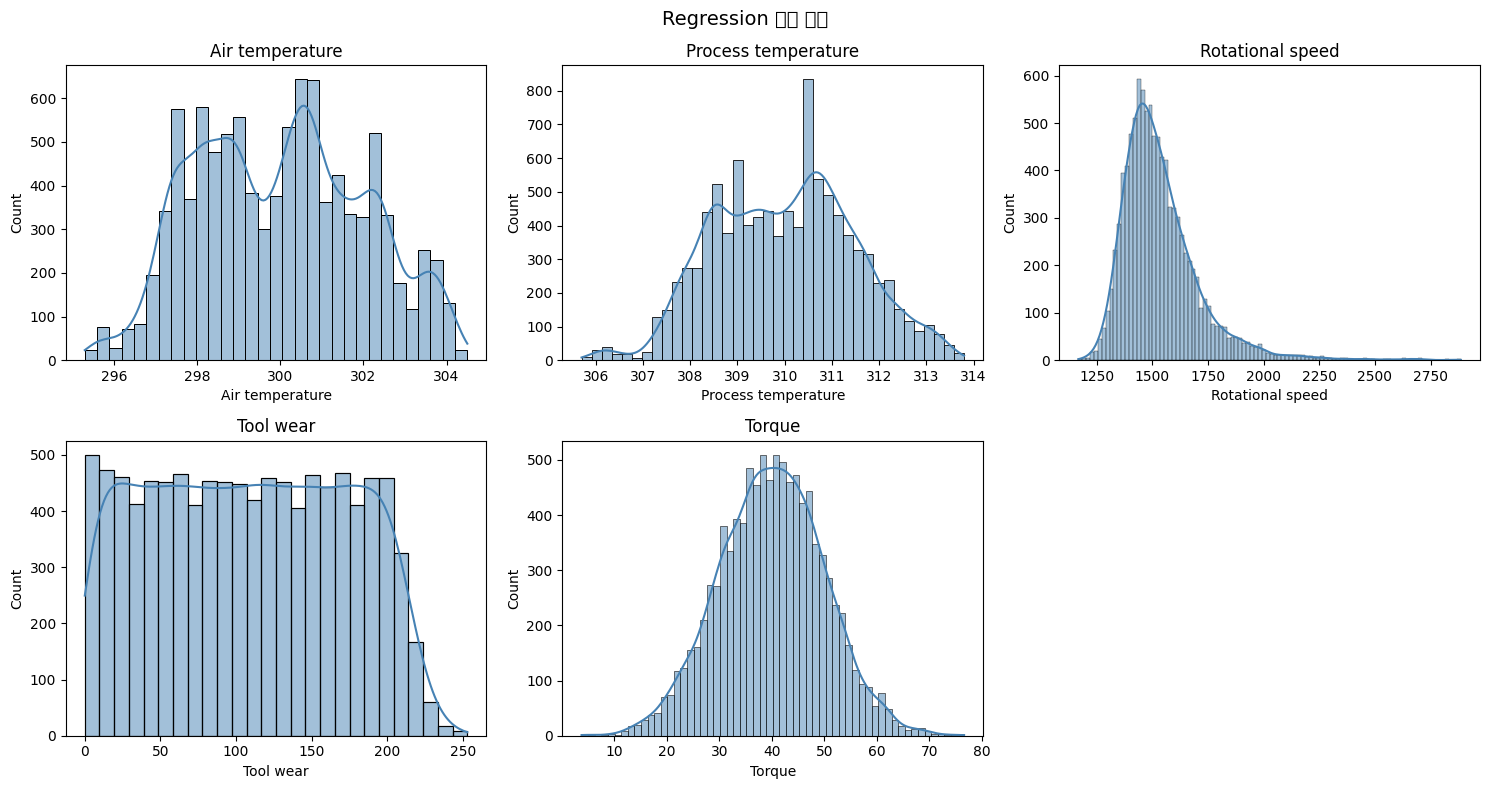

/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/2432153253.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/ho

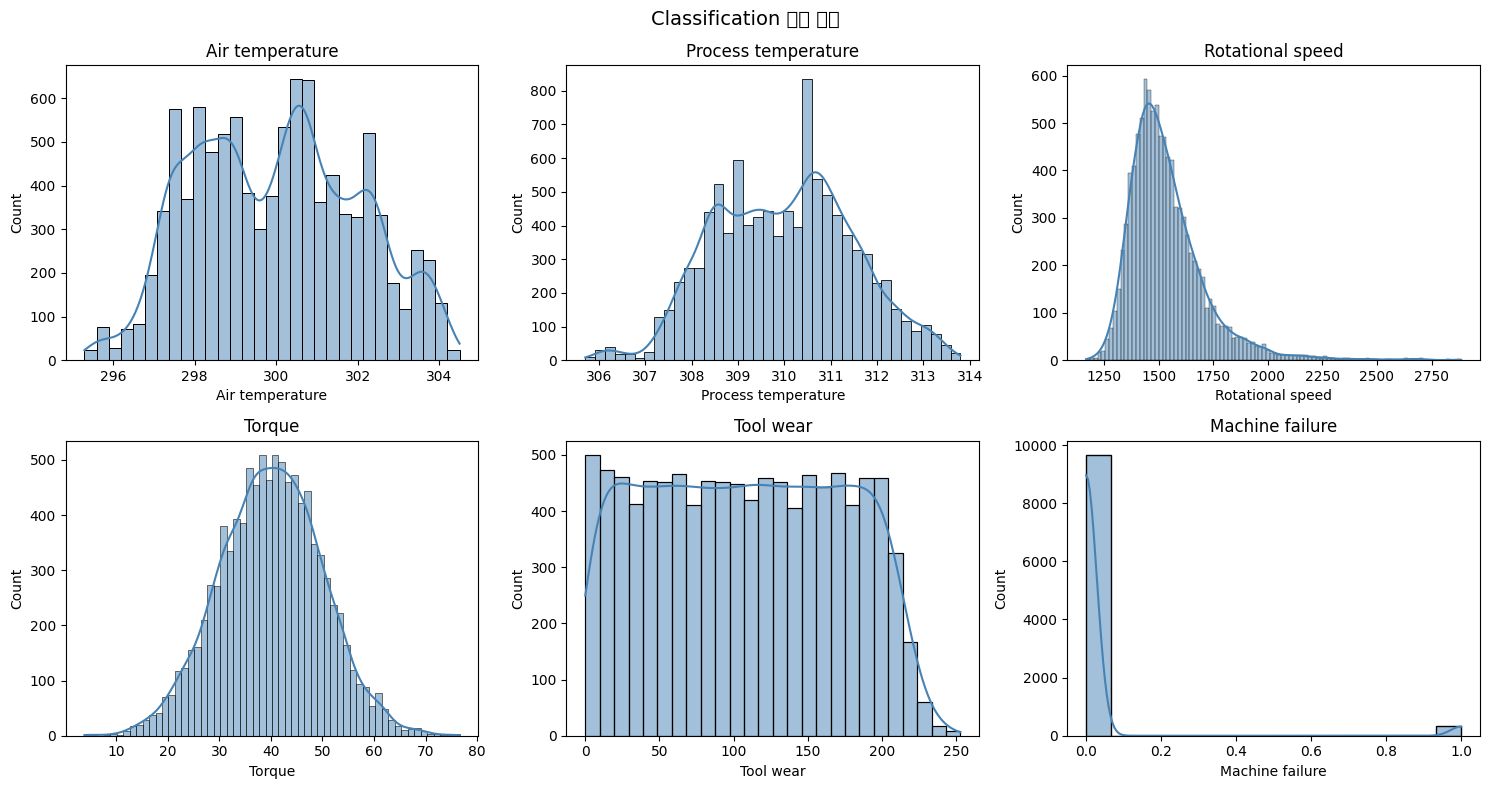

In [19]:
def plot_distributions(df, title=""):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    n = len(num_cols)
    n_cols = 3
    n_rows = -(-n // n_cols)  # 올림 나눗셈

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(col)

    # 남는 subplot 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_distributions(Regression, "Regression 변수 분포")
plot_distributions(Classification, "Classification 변수 분포")

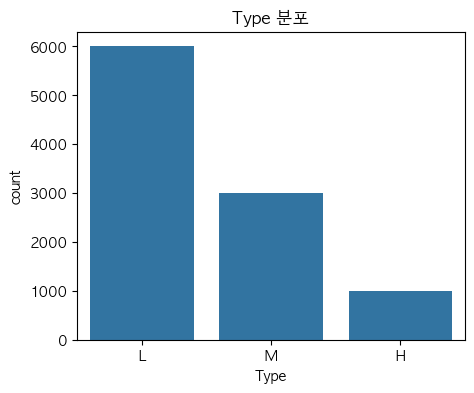

In [29]:
plt.figure(figsize=(5, 4))
sns.countplot(data=Regression, x="Type", order=["L", "M", "H"])
plt.title("Type 분포")
plt.show()

/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/4114312312.py:18: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/4114312312.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


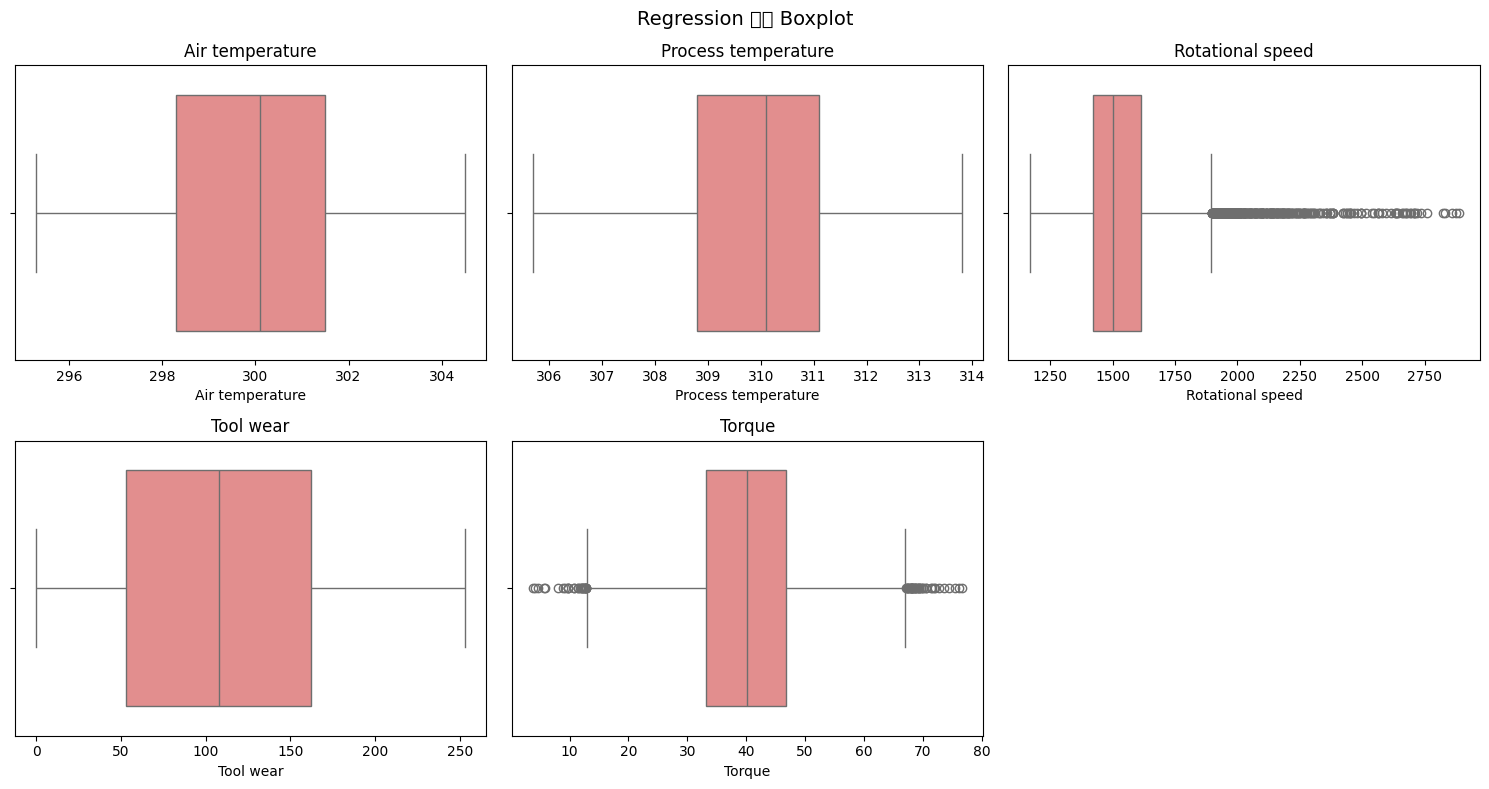

In [21]:
def plot_boxplots(df, title=""):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    n = len(num_cols)
    n_cols = 3
    n_rows = -(-n // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_boxplots(Regression, "Regression 변수 Boxplot")

**[과제]** 써니는 설비 고장이 실제로 얼마나 자주 발생하는지 궁금합니다. 고장 발생 빈도를 확인할 수 있는 방법을 AI와 함께 찾아보고, 그 결과를 시각화하거나 분석해 보세요. 이 결과가 앞으로의 분석(데이터 분할, 성능 평가 등)에 어떤 영향을 줄 수 있을지도 함께 생각해 보세요.

In [22]:
print(Classification["Machine failure"].value_counts())
print()
print(Classification["Machine failure"].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/1058222554.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["정상 (0)", "고장 (1)"])


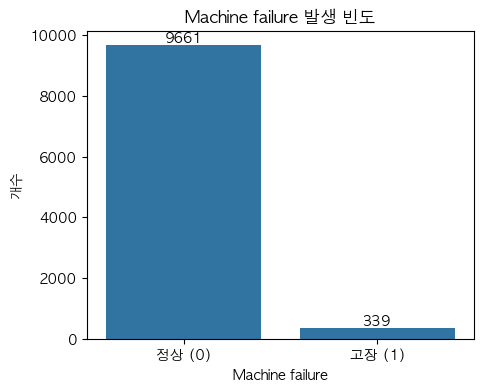

In [27]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=Classification, x="Machine failure")
ax.set_xticklabels(["정상 (0)", "고장 (1)"])

# 막대 위에 개수 표시
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.title("Machine failure 발생 빈도")
plt.ylabel("개수")
plt.show()

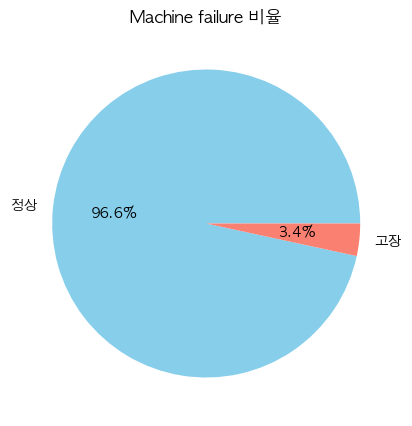

In [28]:
plt.figure(figsize=(5, 5))
Classification["Machine failure"].value_counts().plot.pie(
    labels=["정상", "고장"], autopct="%.1f%%", colors=["skyblue", "salmon"]
)
plt.title("Machine failure 비율")
plt.ylabel("")
plt.show()

In [25]:
counts = Classification["Machine failure"].value_counts()
imbalance_ratio = counts[0] / counts[1]
print(f"정상 : 고장 비율 = {imbalance_ratio:.1f} : 1")

정상 : 고장 비율 = 28.5 : 1


**[과제]** 써니는 설비가 고장 났을 때와 정상일 때 변수들의 분포가 어떻게 다른지 비교하고 싶습니다. 어떻게 비교하면 차이가 잘 드러날지 AI와 상의해서 방법을 정하고 직접 시각화해 보세요.

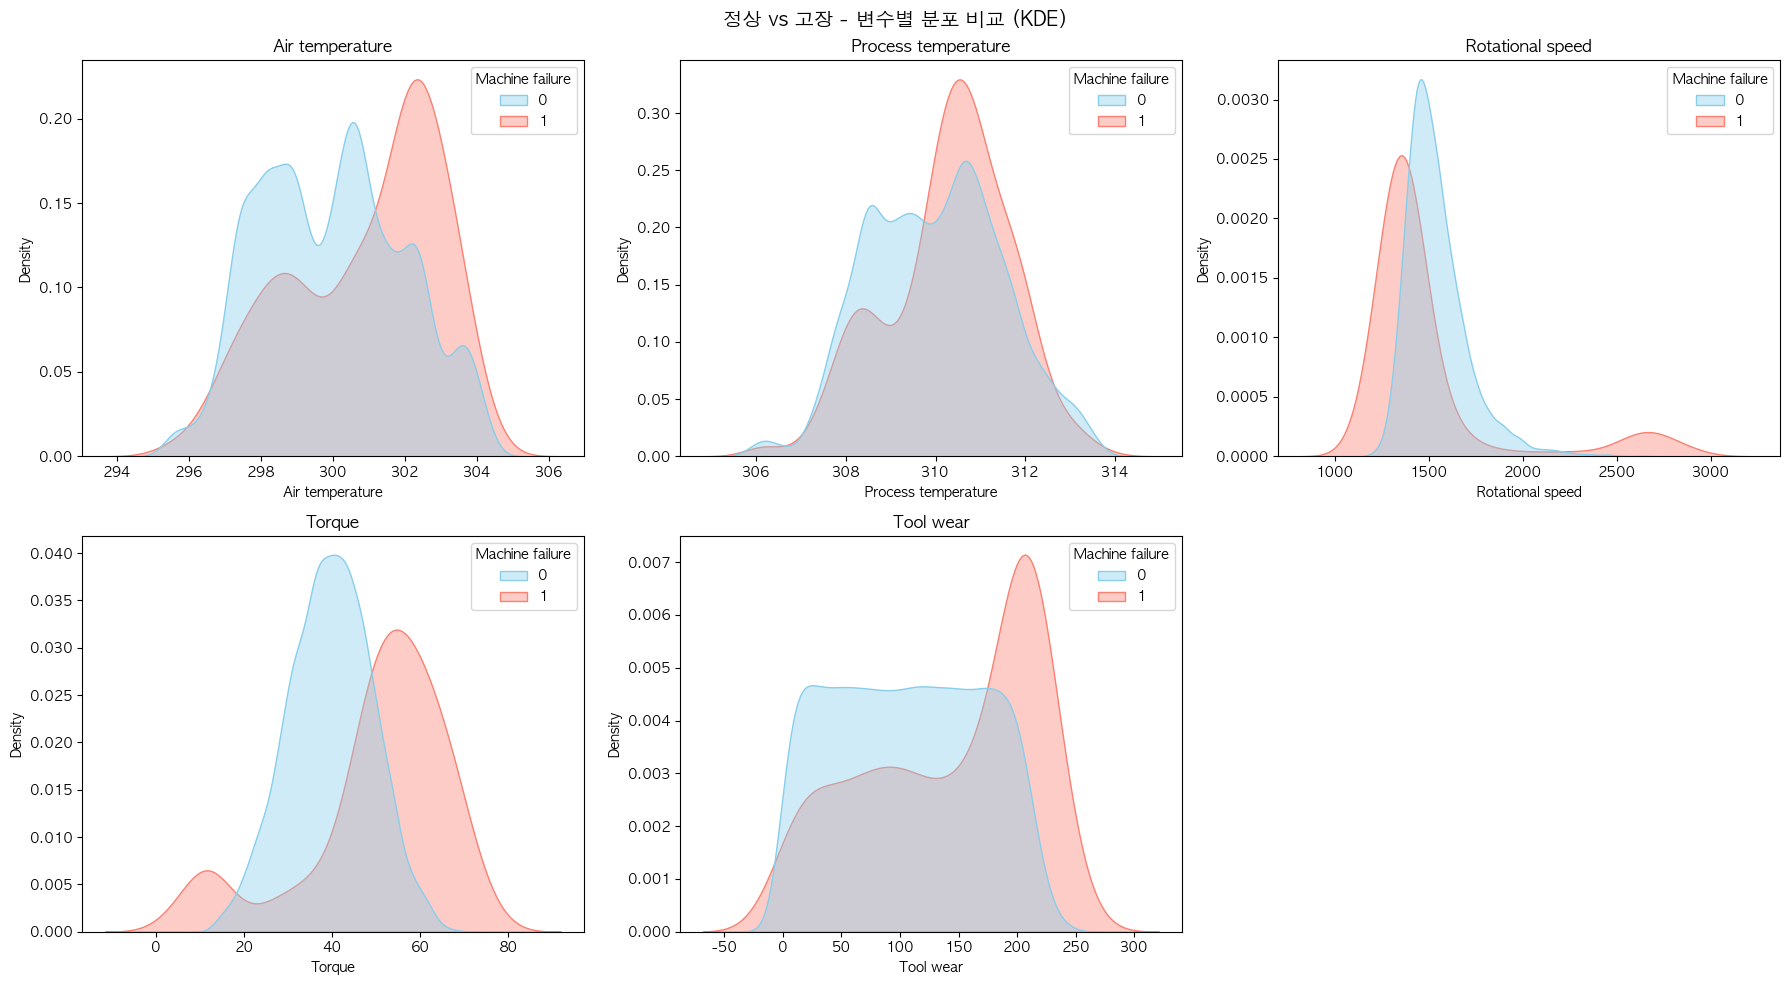

In [30]:
num_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(
        data=Classification, x=col, hue="Machine failure",
        common_norm=False,   # 개수 차이 무시하고 "모양"만 비교
        fill=True, alpha=0.4, ax=axes[i],
        palette={0: "skyblue", 1: "salmon"},
    )
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("정상 vs 고장 - 변수별 분포 비교 (KDE)", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/1008026439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/1008026439.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["정상", "고장"])
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/1008026439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/1008026439.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

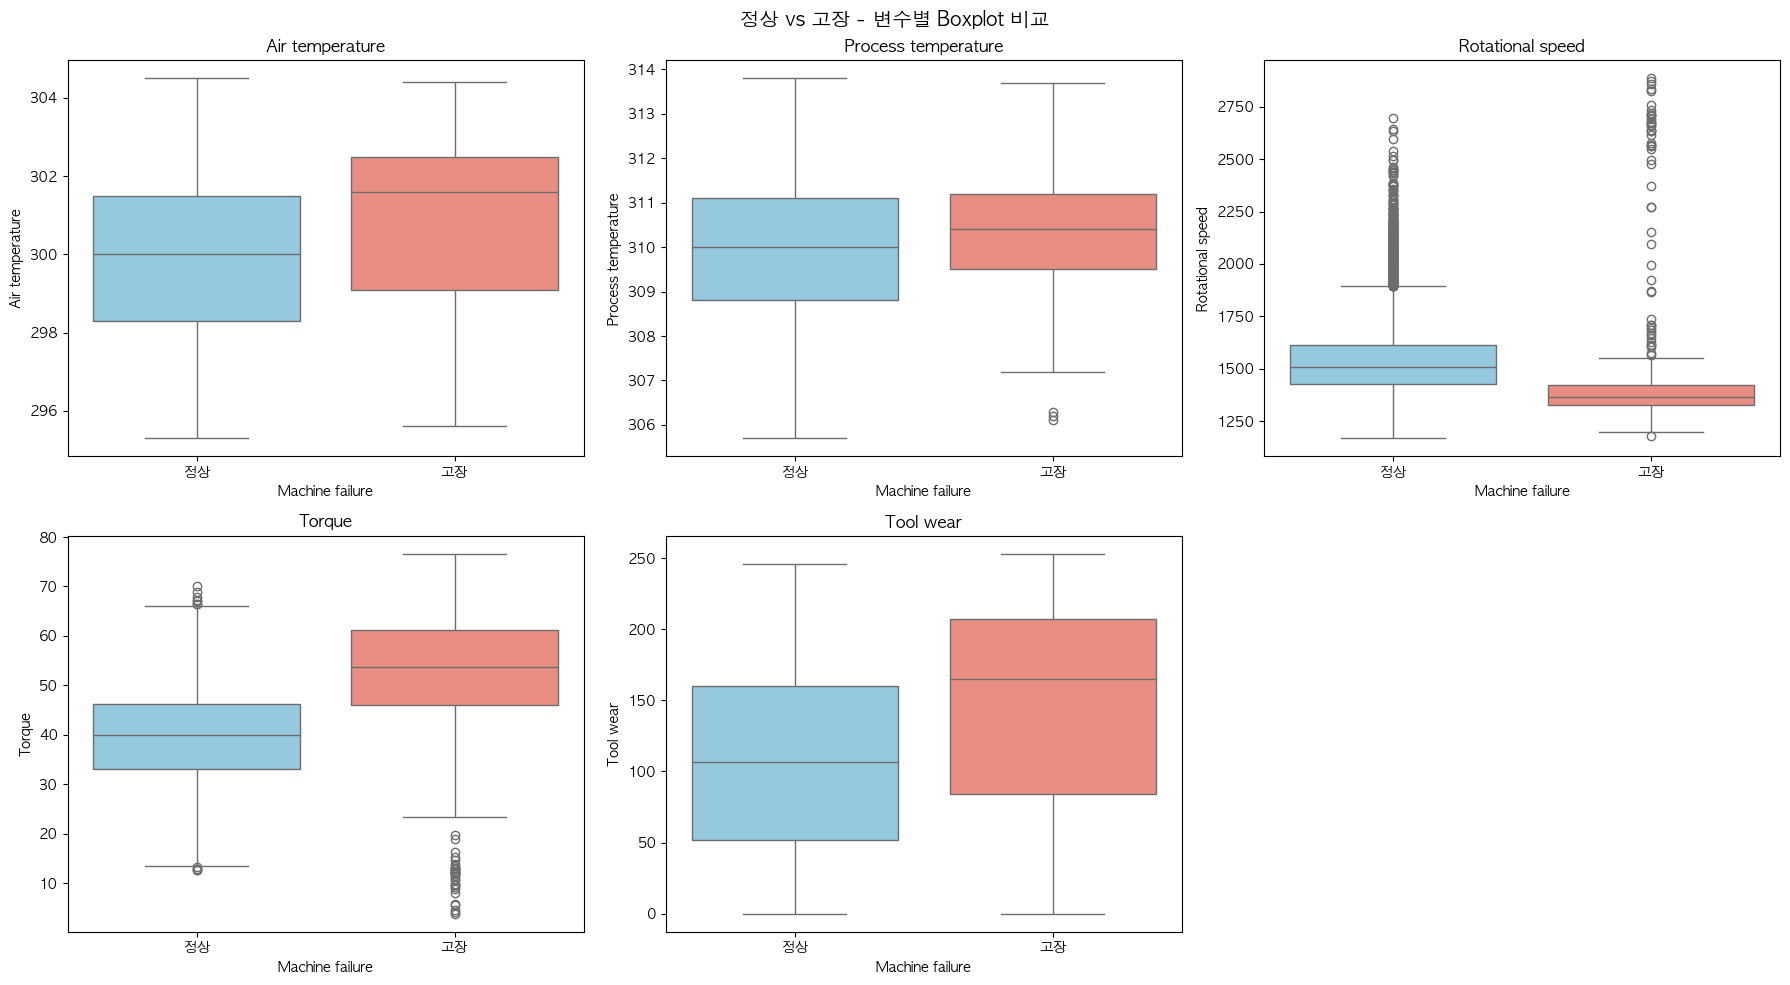

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=Classification, x="Machine failure", y=col,
        ax=axes[i], palette=["skyblue", "salmon"],  # dict 대신 리스트
    )
    axes[i].set_xticklabels(["정상", "고장"])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("정상 vs 고장 - 변수별 Boxplot 비교", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/3933635630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/3933635630.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["정상", "고장"])
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/3933635630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/00/zjgc1bbd15b414rxm4ngpt600000gn/T/ipykernel_86774/3933635630.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

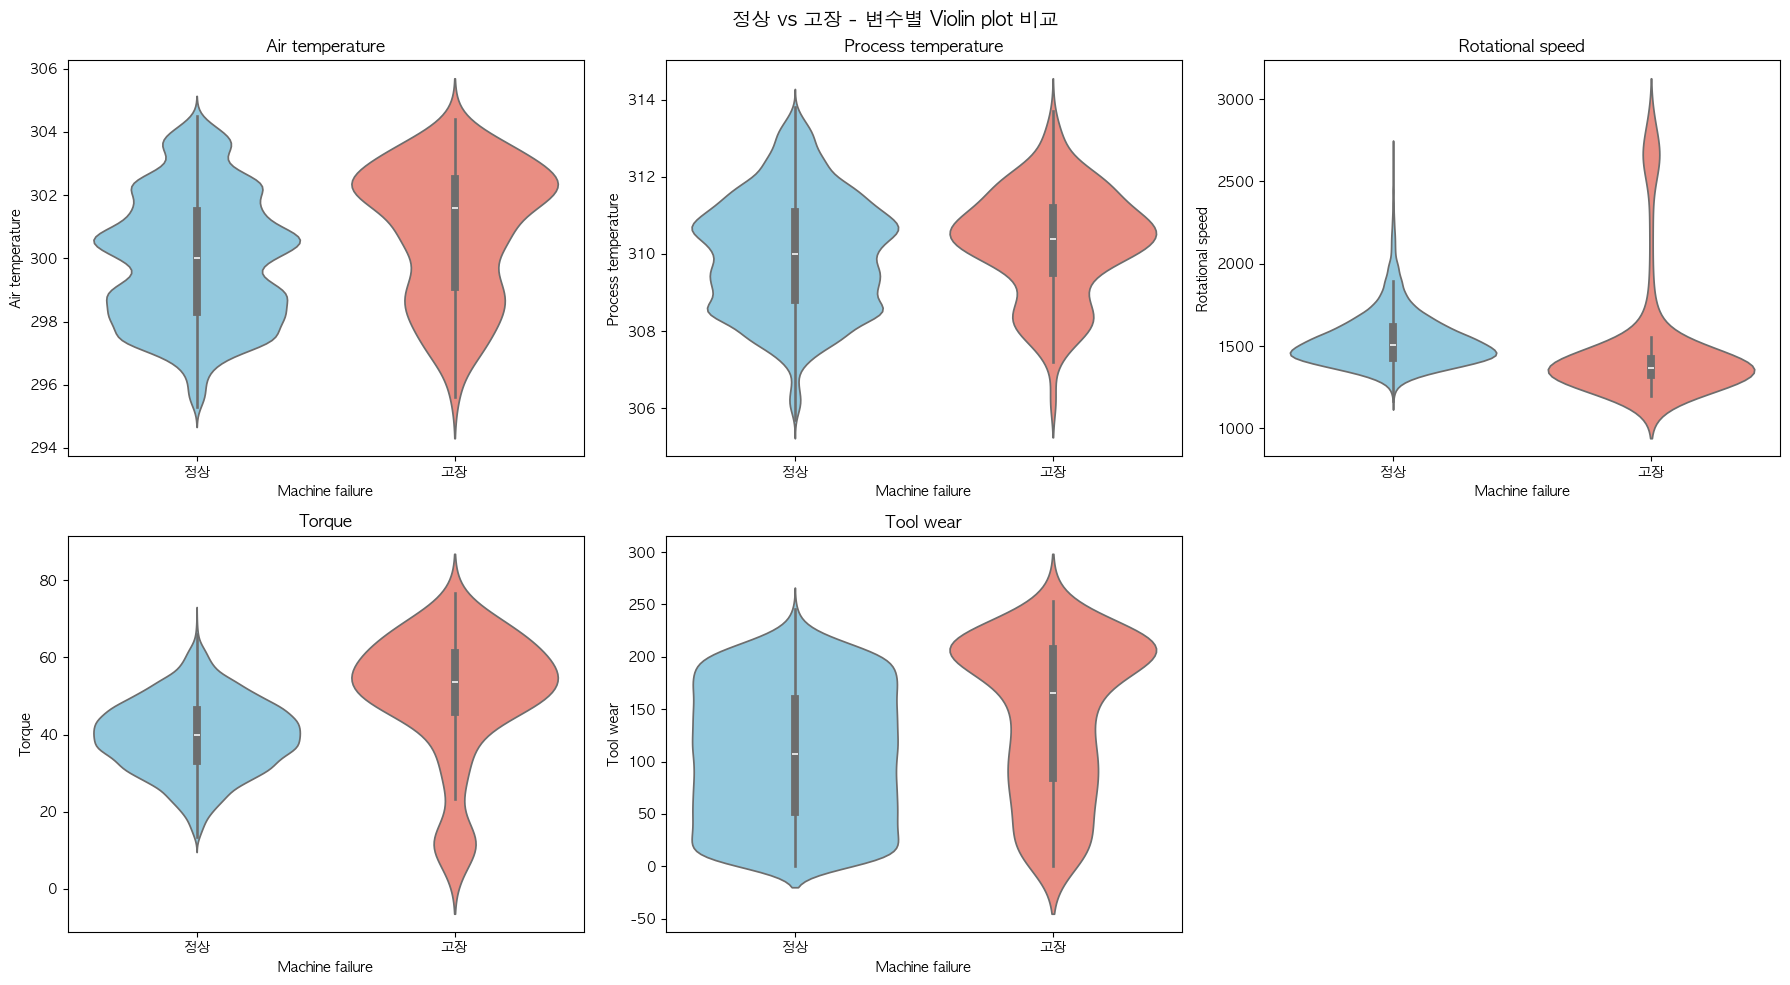

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(
        data=Classification, x="Machine failure", y=col,
        ax=axes[i], palette= ["skyblue", "salmon"],
    )
    axes[i].set_xticklabels(["정상", "고장"])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("정상 vs 고장 - 변수별 Violin plot 비교", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
Classification.groupby("Machine failure")[num_cols].agg(["mean", "std"]).round(2)

Air temperature       Process temperature        \
                           mean   std                mean   std   
Machine failure                                                   
0                        299.97  1.99              310.00  1.49   
1                        300.89  2.07              310.29  1.36   

                Rotational speed         Torque        Tool wear         
                            mean     std   mean    std      mean    std  
Machine failure                                                          
0                        1540.26  167.39  39.63   9.47    106.69  62.95  
1                        1496.49  384.94  50.17  16.37    143.78  72.76

#### 1-2-2) 변수 간 관계

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

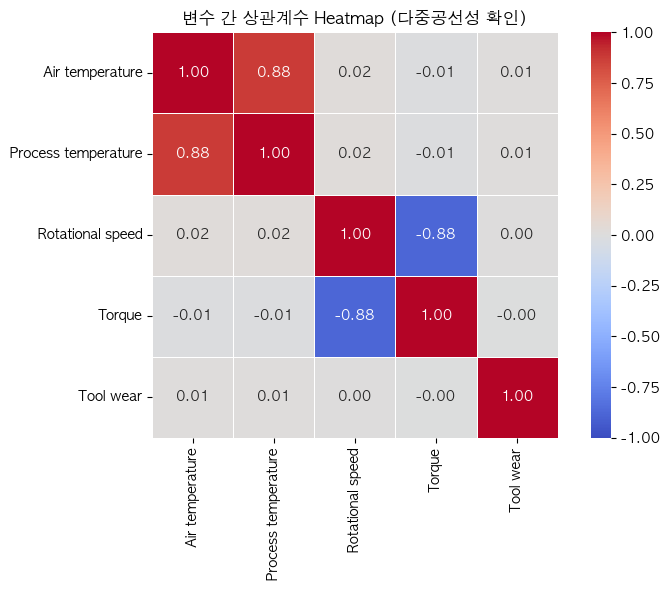

In [38]:
# 수치형 변수만 선택 (Type 제외)
num_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]

corr = Classification[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,          # 숫자 표시
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("변수 간 상관계수 Heatmap (다중공선성 확인)")
plt.tight_layout()
plt.show()

In [39]:
# 상삼각만 사용해서 중복 제거
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["var1", "var2", "corr"]

# 절댓값 0.7 이상만
high_corr = corr_pairs[corr_pairs["corr"].abs() >= 0.7].sort_values("corr", key=abs, ascending=False)
high_corr

,var1,var2,corr
0,Air temperature,Process temperature,0.876107
7,Rotational speed,Torque,-0.875027


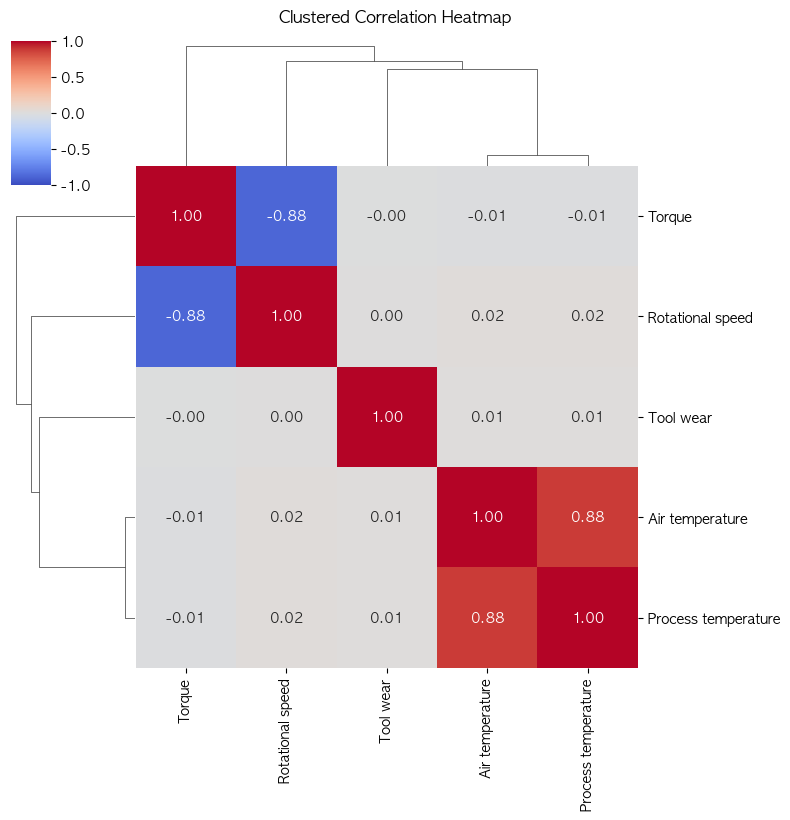

In [40]:
g = sns.clustermap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    figsize=(8, 8),
)
g.fig.suptitle("Clustered Correlation Heatmap", y=1.02)
plt.show()

In [44]:
!pip install statsmodels

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = Classification[num_cols].copy()

vif_df = pd.DataFrame({
    "변수": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
}).sort_values("VIF", ascending=False)

vif_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


,변수,VIF
1,Process temperature,88285.242860
0,Air temperature,87413.106376
2,Rotational speed,315.329872
3,Torque,72.125192
4,Tool wear,3.877244


**[과제]** 써니는 히트맵으로 상관관계가 높은 변수쌍은 찾았지만, 단순한 상관계수만으로 변수들이 서로 얽혀 있는 정도를 다 설명할 수 있을지 의문이 듭니다. 상관계수 외에 변수 간의 강한 관계를 파악할 수 있는 다른 방법이 있는지 AI와 함께 찾아보고, 직접 적용해 보세요.

### Pearson vs Spearman vs MI — 방법 비교

| 방법 | 무엇을 보는가 | 한계 |
|------|--------------|------|
| **Pearson** | 직선 관계 (선형) | 곡선·복잡한 패턴은 놓칠 수 있음 |
| **Spearman** | 순위 기반 단조 관계 | U자형 등 비단조는 못 봄 |
| **MI** | 선형/비선형 구분 없이 정보 공유 | 방향(+/−)은 알 수 없음 |

**해석 팁**
- Pearson·Spearman 둘 다 높음 → **선형에 가까운 강한 관계**
- Spearman만 높음 → **비선형이지만 단조 관계**
- MI는 높은데 Pearson은 낮음 → **비선형·복잡한 관계 의심**

In [ ]:
from sklearn.feature_selection import mutual_info_regression

num_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]
X = Classification[num_cols]

# ── 1) Pearson / Spearman 상관행렬 ──
pearson = X.corr(method="pearson")
spearman = X.corr(method="spearman")

# ── 2) MI(상호정보량) 행렬 — 변수쌍별 ──
n = len(num_cols)
mi_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        mi = mutual_info_regression(
            X[[num_cols[i]]], X[num_cols[j]],
            random_state=42, n_neighbors=3,
        )[0]
        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi

mi_df = pd.DataFrame(mi_matrix, index=num_cols, columns=num_cols)

# ── 3) Heatmap 3종 나란히 비교 ──
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, mat, title in zip(
    axes,
    [pearson, spearman, mi_df],
    ["Pearson (선형)", "Spearman (단조)", "MI (비선형 포함)"],
):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlOrRd", square=True, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# ── 4) 변수쌍별 3지표 통합 표 ──
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "var1": num_cols[i],
            "var2": num_cols[j],
            "Pearson": pearson.iloc[i, j],
            "Spearman": spearman.iloc[i, j],
            "MI": mi_matrix[i, j],
        })

compare_df = pd.DataFrame(pairs)
compare_df["|Pearson|"] = compare_df["Pearson"].abs()
compare_df["|Spearman|"] = compare_df["Spearman"].abs()

# 패턴 자동 분류
def classify_row(row):
    p, s, mi = row["|Pearson|"], row["|Spearman|"], row["MI"]
    mi_thresh = compare_df["MI"].quantile(0.75)
    if p >= 0.7:
        return "선형 의존 (Pearson↑)"
    if s >= 0.7 and p < 0.5:
        return "단조·비선형 (Spearman↑ Pearson↓)"
    if mi >= mi_thresh and p < 0.5:
        return "비선형 의심 (MI↑ Pearson↓)"
    return "약한 관계"

compare_df["패턴"] = compare_df.apply(classify_row, axis=1)
compare_df = compare_df.sort_values("MI", ascending=False).reset_index(drop=True)

print("=== 변수쌍별 Pearson / Spearman / MI 비교 ===")
compare_df.round(4)

# ── 5) Pearson만으로는 부족할 수 있는 쌍 ──
print("\n=== Pearson 낮은데 Spearman 또는 MI가 높은 쌍 ===")
suspicious = compare_df[
    (compare_df["|Pearson|"] < 0.5)
    & ((compare_df["|Spearman|"] >= 0.5) | (compare_df["MI"] >= compare_df["MI"].quantile(0.75)))
]
suspicious.round(4)

---
## 2) 데이터 전처리

### 2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델에 넣기 전에 분석에 도움이 안 되거나, 오히려 결과를 왜곡시킬 수 있는 변수가 있는지 점검하려고 합니다. 어떤 변수를 빼야 하는지, 그 이유는 무엇인지 AI와 상의해서 정리하고 제거해 보세요.

### 2-2) 데이터 분할

**[과제]** 써니는 학습/테스트 데이터를 나누려고 합니다. 회귀용과 분류용 각각에 어떤 분할 방법과 기준이 적합할지 AI와 상의해서 정하고, 그 기준대로 직접 나눠 보세요.

### 2-3) 변수 스케일링

**[과제]** 써니는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 맞춰주고 싶습니다. 변수들의 분포를 보면서 어떤 스케일링 기법이 적합할지 AI와 상의해서 정하고 적용해 보세요.

**[과제]** 써니는 `Type` 변수를 모델에 넣으려면 숫자로 바꿔야 한다는 건 알고 있지만, 원-핫 인코딩과 라벨 인코딩 중 어느 쪽이 맞을지 고민입니다. 어떤 기준으로 선택해야 할지 AI와 상의해서 정하고 적용해 보세요.

---
## 3) 모델링

### 3-1) 모델 생성 및 학습

**[과제]** 써니는 여러 모델의 성능을 한 번에 비교해보고 싶습니다. 회귀와 분류 각각 어떤 모델을 후보로 둘지, 매번 코드를 새로 짜지 않고 효율적으로 비교할 방법은 무엇일지 AI와 상의해서 코드를 작성해 보세요.

### 3-2) 테스트 데이터 예측

**[과제]** 써니는 앞서 학습시킨 회귀 및 분류 모델들로 테스트 데이터에 대한 예측을 수행하려고 합니다. 모든 모델의 예측 결과를 한 번에 뽑을 수 있도록 AI와 함께 코드를 작성해 보세요.

### 3-3) 성능 평가

**[과제]** 써니는 모델 성능을 비교하려고 하는데, 회귀와 분류 각각 사용할 수 있는 지표가 다양해서 무엇을 기준으로 봐야 할지 고민입니다. 적절한 지표를 AI와 상의해서 정하고, 그 기준으로 가장 좋은 모델을 선택해 보세요.

---
## 4) 모델 고도화

**[과제]** 써니는 가장 성능이 좋았던 모델을 더 끌어올리고 싶습니다. 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 AI와 상의해서 정하고, 그 기준으로 성능을 높여 보세요.

---
## 5) 모델 결과 분석

**[과제]** 써니는 최종적으로 어떤 운전 조건이 토크와 고장에 가장 큰 영향을 미치는지 정리해서 보고하려고 합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델의 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아본 뒤, 그 결과로부터 인사이트를 도출해 보세요.